# Plot data and ROI

In [69]:
import os
import warnings
from abc import ABC, abstractmethod
from copy import deepcopy
from functools import lru_cache
from typing import List, Union, Type, Tuple

import numpy as np
import blosc2
import shutil
from blosc2 import Filter, Codec
from batchgenerators.utilities.file_and_folder_operations import join, load_pickle, isfile, write_pickle, subfiles
# from nnunetv2.configuration import default_num_processes

import math



## Plot before and after register

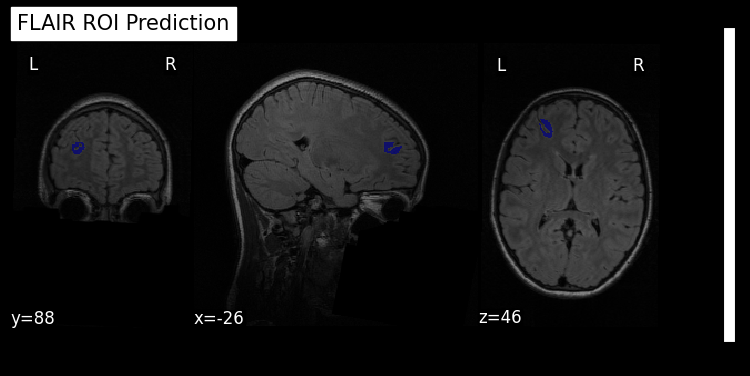

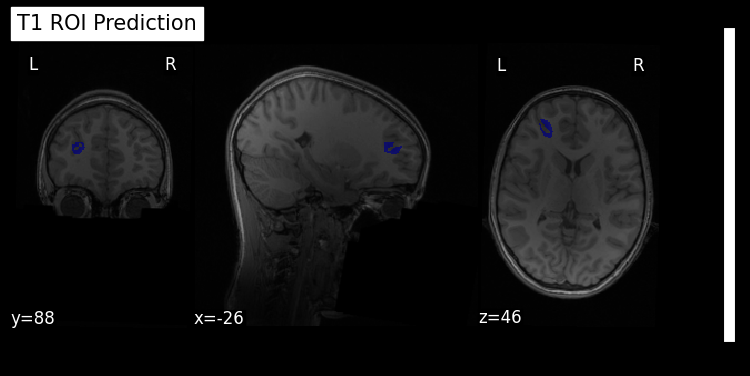

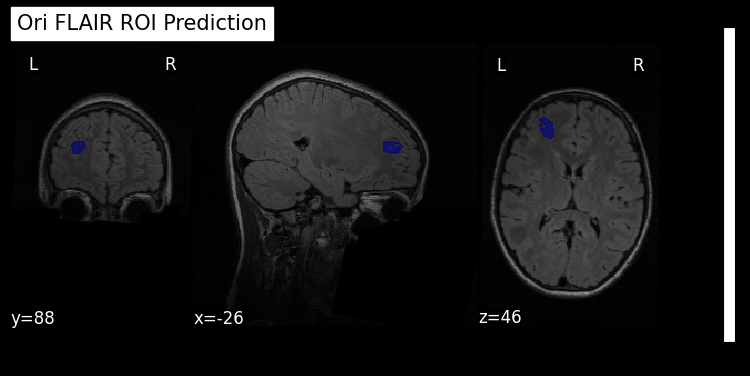

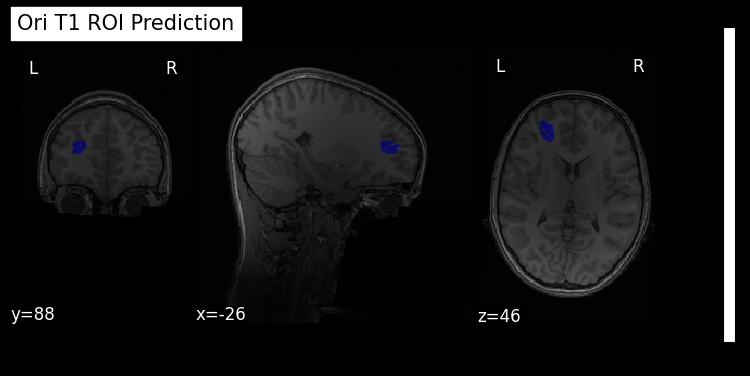

In [168]:
from nilearn import plotting
from nilearn import image
T1_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00091_0000.nii.gz'
flair_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00091_0001.nii.gz'
roi_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/labelsTr/FCD_00091.nii.gz'
roi_image = image.load_img(roi_path)
flair_image = image.load_img(flair_path)
T1_image = image.load_img(T1_path)
plotting.plot_roi(roi_image,bg_img=flair_image,draw_cross=False,title='FLAIR ROI Prediction')
plotting.plot_roi(roi_image,bg_img=T1_image,draw_cross=False,title='T1 ROI Prediction')

ori_T1_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00091/anat/sub-00091_acq-sag111_T1w.nii.gz'
ori_flair_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00091/anat/sub-00091_acq-tse3dvfl_FLAIR.nii.gz'
ori_roi_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00091/anat/sub-00091_acq-tse3dvfl_FLAIR_roi.nii.gz'
ori_roi_image = image.load_img(ori_roi_path)
ori_flair_image = image.load_img(ori_flair_path)
ori_T1_image = image.load_img(ori_T1_path)
plotting.plot_roi(ori_roi_image,bg_img=ori_flair_image,draw_cross=False,title='Ori FLAIR ROI Prediction')
plotting.plot_roi(ori_roi_image,bg_img=ori_T1_image,draw_cross=False,title='Ori T1 ROI Prediction')


## Plot before and after resample

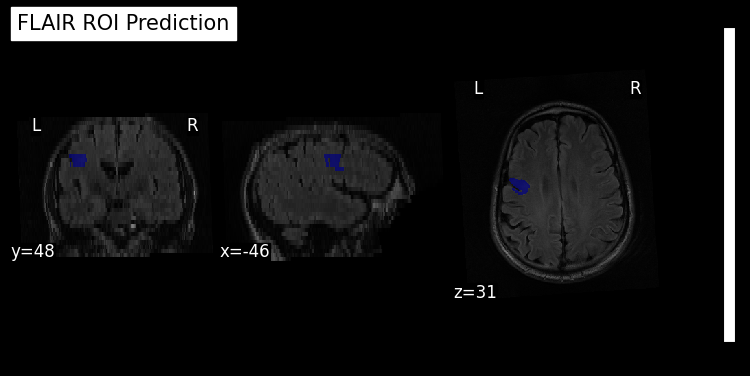

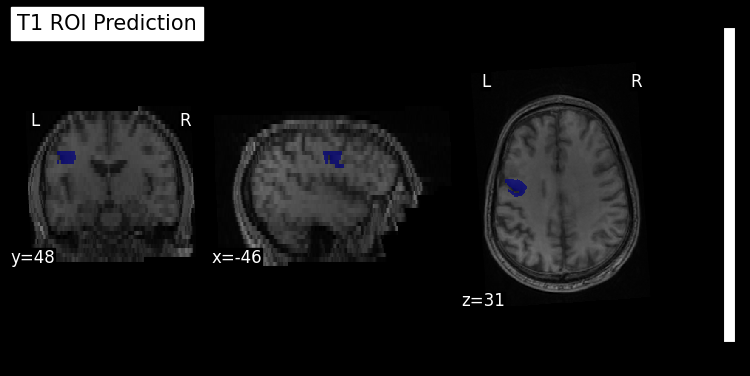

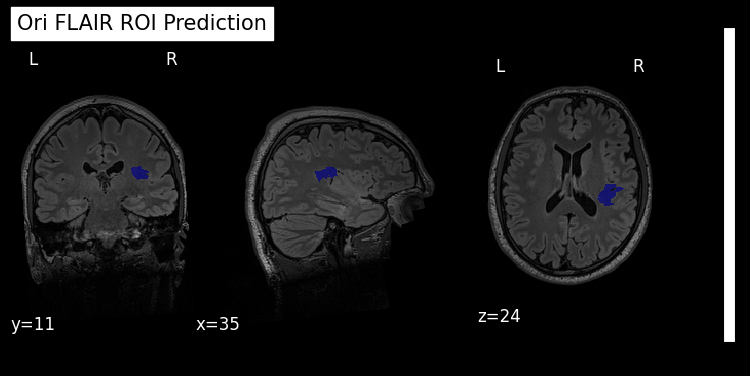

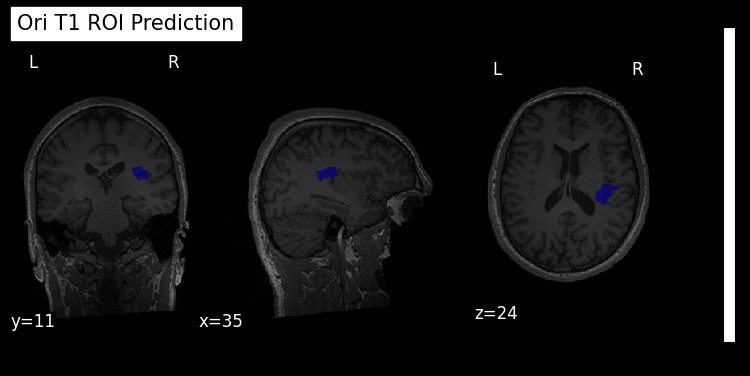

In [78]:
from nilearn import plotting
from nilearn import image
T1_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00112_0000.nii.gz'
flair_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00112_0001.nii.gz'
roi_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/labelsTr/FCD_00112.nii.gz'
roi_image = image.load_img(roi_path)
flair_image = image.load_img(flair_path)
T1_image = image.load_img(T1_path)
plotting.plot_roi(roi_image,bg_img=flair_image,draw_cross=False,title='FLAIR ROI Prediction')
plotting.plot_roi(roi_image,bg_img=T1_image,draw_cross=False,title='T1 ROI Prediction')

ori_T1_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-iso08_T1w.nii.gz'
ori_flair_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR.nii.gz'
ori_roi_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR_roi.nii.gz'
ori_roi_image = image.load_img(ori_roi_path)
ori_flair_image = image.load_img(ori_flair_path)
ori_T1_image = image.load_img(ori_T1_path)
plotting.plot_roi(ori_roi_image,bg_img=ori_flair_image,draw_cross=False,title='Ori FLAIR ROI Prediction')
plotting.plot_roi(ori_roi_image,bg_img=ori_T1_image,draw_cross=False,title='Ori T1 ROI Prediction')


# Print data shape before and after register, preprocess of openeuro and prostate dataset

In [70]:
def get_shape_of_niigz(path):
    # flair_image = image.load_img(path)
    # _array = flair_image.get_fdata()
    _array = sitk.GetArrayFromImage(sitk.ReadImage(path))
    print( _array.shape, path)  # (D, H, W)

def load_case(source_folder, identifier):
    dparams = {
        'nthreads': 1
    }
    data_b2nd_file = join(source_folder, identifier + '.b2nd')
    # mmap does not work with Windows -> https://github.com/MIC-DKFZ/nnUNet/issues/2723
    mmap_kwargs = {} if os.name == "nt" else {'mmap_mode': 'r'}
    data = blosc2.open(urlpath=data_b2nd_file, mode='r', dparams=dparams, **mmap_kwargs)
    seg_b2nd_file = join(source_folder, identifier + '_seg.b2nd')
    seg = blosc2.open(urlpath=seg_b2nd_file, mode='r', dparams=dparams, **mmap_kwargs)
    properties = load_pickle(join(source_folder, identifier + '.pkl'))
    return data, seg, properties

In [169]:


print('\n before everything')
path =[
    '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR.nii.gz',
    '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-iso08_T1w.nii.gz',
    '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR_roi.nii.gz'
]
for i in path :
    get_shape_of_niigz(i)
    
print('\n after register')
path = [
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00001_0000.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00001_0001.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/labelsTr/FCD_00001.nii.gz'
    
]
for i in path :
    get_shape_of_niigz(i)
    
print('\n after preprocess')
path = [
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset108_FCD/gt_segmentations/FCD_00001.nii.gz',
]
for i in path :
    get_shape_of_niigz(i)

source_folder = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset108_FCD/nnUNetPlans_2d/'
identifier = 'FCD_00001'
data, seg, properties = load_case(source_folder, identifier)
print(data.shape,'\n' ,seg.shape)


print('***reference dataset***')
print('\n before everything')
path =[
    '/home/qingyu/datasets/Task05_Prostate/imagesTr/prostate_00.nii.gz',
    '/home/qingyu/datasets/Task05_Prostate/labelsTr/prostate_00.nii.gz',
]
for i in path :
    get_shape_of_niigz(i)
    
print('\n after transfer')
path = [
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/imagesTr/prostate_00_0000.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/imagesTr/prostate_00_0001.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/labelsTr/prostate_00.nii.gz'
    
]
for i in path :
    get_shape_of_niigz(i)
    
print('\n after preprocess')
path = [
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset005_Prostate/gt_segmentations/prostate_00.nii.gz',
]
for i in path :
    get_shape_of_niigz(i)

source_folder = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset005_Prostate/nnUNetPlans_2d'
identifier = 'prostate_00'
data, seg, properties = load_case(source_folder, identifier)
print(data.shape,'\n' ,seg.shape)






 before everything
(256, 256, 160) /home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR.nii.gz
(320, 320, 208) /home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-iso08_T1w.nii.gz
(256, 256, 160) /home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR_roi.nii.gz

 after register
(256, 256, 160) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00001_0000.nii.gz
(256, 256, 160) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00001_0001.nii.gz
(256, 256, 160) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/labelsTr/FCD_00001.nii.gz

 after preprocess
(256, 256, 160) /home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset108_FCD/gt_segmentations/FCD_00001.nii.gz
(2, 256, 256, 160) 
 (1, 256, 256, 160)
***reference dataset***

 before everything
(2, 15, 320, 320) /home/qingyu/datasets/Task05_Prostate/imagesTr/prostate_00.nii.gz
(15, 320, 320) /home/qingyu/datasets/Tas

In [103]:
print(seg.chunks)

(1, 1, 307, 307)


In [ ]:
ori_T1_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-iso08_T1w.nii.gz'
ori_flair_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR.nii.gz'
ori_roi_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR_roi.nii.gz'
ori_roi_image = image.load_img(ori_roi_path)
ori_flair_image = image.load_img(ori_flair_path)
ori_T1_image = image.load_img(ori_T1_path)
plotting.plot_roi(ori_roi_image,bg_img=ori_flair_image,draw_cross=False,title='Ori FLAIR ROI Prediction')
plotting.plot_roi(ori_roi_image,bg_img=ori_T1_image,draw_cross=False,title='Ori T1 ROI Prediction')

In [36]:
print(image.get_data(roi_image).shape)
print(image.get_data(flair_image).shape)
print(image.get_data(T1_image).shape)



(320, 320, 208)
(320, 320, 208)
(320, 320, 208)


In [35]:
arr.shape

(208, 320, 320)

/tmp/ipykernel_1810203/3701625340.py:6: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.plot_roi(flair_roi_image,bg_img=flair_image,draw_cross=False,title='FLAIR ROI Ground Truth')
/tmp/ipykernel_1810203/3701625340.py:6: UserWarning: empty mask
  plotting.plot_roi(flair_roi_image,bg_img=flair_image,draw_cross=False,title='FLAIR ROI Ground Truth')
/home/qingyu/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,
/home/qingyu/anaconda3/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:539: UserWarning: Warning: converting a masked element to nan.
  vmin=float(kwargs.get("vmin")),
/home/qingyu/anaconda3/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:540: UserWarning: Warning: converting a masked element to nan.
  vmax=float(kwargs.get("vmax")),


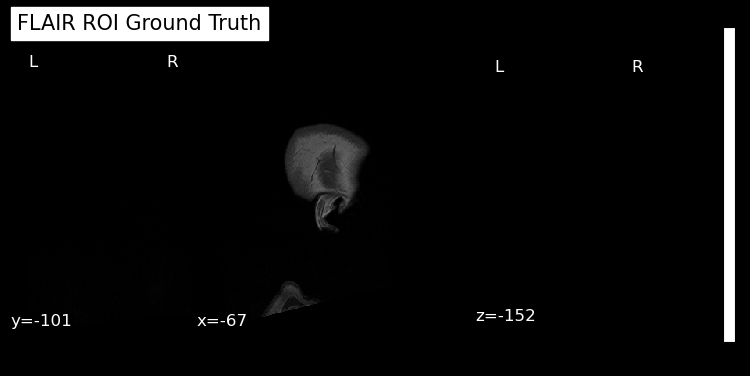

In [57]:
flair_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/imagesTr/FCD_00002_0000.nii.gz'
roi_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/labelsTr/FCD_00002.nii.gz'
flair_roi_image = image.load_img(roi_path)
flair_image = image.load_img(flair_path)

plotting.plot_roi(flair_roi_image,bg_img=flair_image,draw_cross=False,title='FLAIR ROI Ground Truth')

In [ ]:
flair_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/imagesTr/FCD_00001_0000.nii.gz'
roi_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_predictions/FCD_00001.nii.gz'
flair_roi_image = image.load_img(roi_path)
flair_image = image.load_img(flair_path)

plotting.plot_roi(flair_roi_image,bg_img=flair_image,draw_cross=False,title='FLAIR ROI')

In [38]:
perturbation_np = np.load('perturbation_np.npy')
data_np = np.load('data_np.npy')
adversarial_image_np = np.load('adversarial_image_np.npy')



In [40]:
perturbation_np.shape


(32, 2, 320, 320)

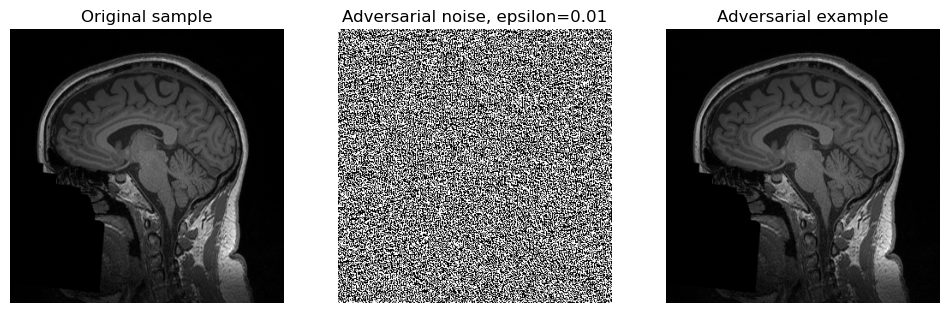

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3,figsize=(12, 12))
ax1 = plt.subplot(1,3,1)  # 选出并返回子图1
# Display and save the grayscale image
plt.axis('off')  # Remove axes

plt.imshow(data_np[0][0], cmap='gray')
plt.title("Original sample")
ax2 = plt.subplot(1,3,2)  # 选出并返回子图1
plt.axis('off')  # Remove axes

plt.title("Adversarial noise, epsilon=0.01")
plt.imshow(perturbation_np[0][0], cmap='gray')
ax3 = plt.subplot(1,3,3)  # 选出并返回子图1
plt.axis('off')  # Remove axes

plt.title("Adversarial example")
plt.imshow(adversarial_image_np[0][0], cmap='gray')
plt.show()
fig.savefig('pictures.png',bbox_inches='tight')#, 
               # transparent=True,
               # pad_inches=0)
plt.close()

In [43]:
perturbation_np[0][0].shape

(320, 320)

In [92]:
path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset106_FCD/nnUNetTrainer_1epochs__nnUNetPlans__2d/fold_0/validation/FCD_00021.nii.gz'
# path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset106_FCD/gt_segmentations/FCD_00021.nii.gz'
flair_image = image.load_img(path)
flair_array = flair_image.get_fdata()
print(flair_array.shape, 'pre')

(320, 320, 208) pre


In [91]:
# path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset106_FCD/nnUNetTrainer_1epochs__nnUNetPlans__2d/fold_0/validation/FCD_00021.nii.gz'
path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset106_FCD/gt_segmentations/FCD_00021.nii.gz'
flair_image = image.load_img(path)
flair_array = flair_image.get_fdata()
print(flair_array.shape, 'gt')

(208, 320, 320) gt


In [92]:
import SimpleITK as sitk

path = [
 '/home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset108_FCD/nnUNetTrainer_50epochs__plans__2d/fold_0/validation/FCD_00007.nii.gz',
 '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset108_FCD/gt_segmentations/FCD_00007.nii.gz',
 '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/labelsTr/FCD_00007.nii.gz',
 '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset108_FCD/imagesTr/FCD_00007_0000.nii.gz',
 '/home/qingyu/datasets/ds004199-1.0.6/sub-00007/anat/sub-00007_acq-iso08_T1w.nii.gz'
]


path = [
'/home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset005_Prostate/nnUNetTrainer__nnUNetPlans__2d/fold_1/validation/prostate_10.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset005_Prostate/gt_segmentations/prostate_10.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/imagesTr/prostate_10_0000.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/imagesTr/prostate_10_0001.nii.gz',
    '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/labelsTr/prostate_10.nii.gz',
    '/home/qingyu/datasets/Task05_Prostate/imagesTr/prostate_10.nii.gz',
    '/home/qingyu/datasets/Task05_Prostate/labelsTr/prostate_10.nii.gz'
    
    
]

for i in path :
    flair_image = sitk.ReadImage(i)
# flair_array = sitk.GetArrayFromImage(flair_image)

    print(flair_image.GetSize(), 'pre')  # (D, H, W)


(320, 320, 20) pre
(320, 320, 20) pre
(320, 320, 20) pre
(320, 320, 20) pre
(320, 320, 20) pre
(320, 320, 20, 2) pre
(320, 320, 20) pre


In [4]:
import SimpleITK as sitk

path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset106_FCD/gt_segmentations/FCD_00021.nii.gz'

flair_image = sitk.ReadImage(path)
flair_array = sitk.GetArrayFromImage(flair_image)

print(flair_array.shape, 'gt')  # (D, H, W)


(320, 320, 208) gt


In [23]:
origin_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR.nii.gz'
origin_roi_path = '/home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR_roi.nii.gz'
raw_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/imagesTr/FCD_00001_0000.nii.gz'
raw_roi_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/labelsTr/FCD_00001.nii.gz'
preprocessed_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset106_FCD/gt_segmentations/FCD_00001.nii.gz'
predicted_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset106_FCD/nnUNetTrainer_1epochs__nnUNetPlans__2d/fold_2/validation/FCD_00001.nii.gz'

In [37]:
from nilearn import image
all = [origin_path, origin_roi_path, raw_path, raw_roi_path, preprocessed_path,predicted_path,flair_path]
for path in all:
    flair_image = image.load_img(path)
    _array = flair_image.get_fdata()
    # _array = sitk.GetArrayFromImage(sitk.ReadImage(path))
    print( _array.shape, path)  # (D, H, W)


(160, 256, 256) /home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR.nii.gz
(160, 256, 256) /home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR_roi.nii.gz
(208, 320, 320) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/imagesTr/FCD_00001_0000.nii.gz
(208, 320, 320) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/labelsTr/FCD_00001.nii.gz
(208, 320, 320) /home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset106_FCD/gt_segmentations/FCD_00001.nii.gz
(320, 320, 208) /home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset106_FCD/nnUNetTrainer_1epochs__nnUNetPlans__2d/fold_2/validation/FCD_00001.nii.gz
(320, 320, 208) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset107_FCD/imagesTr/FCD_00001_0001.nii.gz


In [19]:
origin_path = '/home/qingyu/datasets/Task05_Prostate/imagesTr/prostate_00.nii.gz'
origin_roi_path = '/home/qingyu/datasets/Task05_Prostate/labelsTr/prostate_00.nii.gz'
raw_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/imagesTr/prostate_00_0000.nii.gz'
raw_roi_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset005_Prostate/labelsTr/prostate_00.nii.gz'
preprocessed_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset005_Prostate/gt_segmentations/prostate_00.nii.gz'
predicted_path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset005_Prostate/nnUNetTrainer_1epochs__nnUNetPlans__2d/fold_2/validation/prostate_17.nii.gz'

In [39]:
from nilearn import image
# all = [origin_path, origin_roi_path, raw_path, raw_roi_path, preprocessed_path,predicted_path]
for path in all:
    # flair_image = image.load_img(path)
    # _array = flair_image.get_fdata()
    _array = sitk.GetArrayFromImage(sitk.ReadImage(path))
    print( _array.shape, path)  # (D, H, W)


(256, 256, 160) /home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR.nii.gz
(256, 256, 160) /home/qingyu/datasets/ds004199-1.0.6/sub-00001/anat/sub-00001_acq-T2sel_FLAIR_roi.nii.gz
(320, 320, 208) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/imagesTr/FCD_00001_0000.nii.gz
(320, 320, 208) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset106_FCD/labelsTr/FCD_00001.nii.gz
(320, 320, 208) /home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset106_FCD/gt_segmentations/FCD_00001.nii.gz
(208, 320, 320) /home/qingyu/code/nnUNet/DATASET/nnUNet_results/Dataset106_FCD/nnUNetTrainer_1epochs__nnUNetPlans__2d/fold_2/validation/FCD_00001.nii.gz
(208, 320, 320) /home/qingyu/code/nnUNet/DATASET/nnUNet_raw/Dataset107_FCD/imagesTr/FCD_00001_0001.nii.gz


In [ ]:
import os
import nibabel as nib

folder = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset106_FCD/gt_segmentations/'

for fname in sorted(os.listdir(folder)):
    if fname.endswith('.nii.gz'):
        fpath = os.path.join(folder, fname)
        img = nib.load(fpath)
        arr = img.get_fdata()
        print(f"{fname}: {arr.shape}")


# Print data shape of preprocessed data

In [58]:
import os
import warnings
from abc import ABC, abstractmethod
from copy import deepcopy
from functools import lru_cache
from typing import List, Union, Type, Tuple

import numpy as np
import blosc2
import shutil
from blosc2 import Filter, Codec
from batchgenerators.utilities.file_and_folder_operations import join, load_pickle, isfile, write_pickle, subfiles
# from nnunetv2.configuration import default_num_processes

import math


preproc_dir = Path("/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset107_FCD/nnUNetPlans_2d")

# Example: iterate all .b2nd files
# for b2nd_file in preproc_dir.glob("*.b2nd"):
b2nd_file = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset107_FCD/nnUNetPlans_2d/FCD_00001_seg.b2nd'

def load_case(source_folder, identifier):
    dparams = {
        'nthreads': 1
    }
    data_b2nd_file = join(source_folder, identifier + '.b2nd')
    # mmap does not work with Windows -> https://github.com/MIC-DKFZ/nnUNet/issues/2723
    mmap_kwargs = {} if os.name == "nt" else {'mmap_mode': 'r'}
    data = blosc2.open(urlpath=data_b2nd_file, mode='r', dparams=dparams, **mmap_kwargs)
    seg_b2nd_file = join(source_folder, identifier + '_seg.b2nd')
    seg = blosc2.open(urlpath=seg_b2nd_file, mode='r', dparams=dparams, **mmap_kwargs)
    properties = load_pickle(join(source_folder, identifier + '.pkl'))
    return data, seg, properties

In [68]:
source_folder = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset107_FCD/nnUNetPlans_2d/'
identifier = 'FCD_00001'
data, seg, properties = load_case(source_folder, identifier)
print(data.shape, seg.shape)
path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset107_FCD/gt_segmentations/FCD_00001.nii.gz'
_array = sitk.GetArrayFromImage(sitk.ReadImage(path))
print( _array.shape, path)  # (D, H, W)


(2, 320, 208, 320) (1, 320, 208, 320)
(208, 320, 320) /home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset107_FCD/gt_segmentations/FCD_00001.nii.gz


In [67]:
source_folder = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset005_Prostate/nnUNetPlans_2d/'
identifier = 'prostate_00'
data, seg, properties = load_case(source_folder, identifier)
print(data.shape, seg.shape)
path = '/home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset005_Prostate/gt_segmentations/prostate_00.nii.gz'
_array = sitk.GetArrayFromImage(sitk.ReadImage(path))
print( _array.shape, path)  # (D, H, W)


(2, 15, 307, 307) (1, 15, 307, 307)
(15, 320, 320) /home/qingyu/code/nnUNet/DATASET/nnUNet_preprocessed/Dataset005_Prostate/gt_segmentations/prostate_00.nii.gz


(1, 320, 208, 320)

In [63]:
properties

{'sitk_stuff': {'spacing': (0.800000011920929,
   0.7999998927116394,
   0.800000011920929),
  'origin': (78.9659652709961, 83.86509704589844, -132.26315307617188),
  'direction': (0.06828262016524785,
   -0.9970473636271666,
   -0.035128884628096324,
   0.10420176218153922,
   0.04214587378354088,
   -0.9936627786634169,
   0.9922093914802612,
   0.06418940728140683,
   0.1067719240422466)},
 'spacing': [np.float64(0.800000011920929),
  np.float64(0.7999998927116394),
  np.float64(0.800000011920929)],
 'shape_before_cropping': (320, 208, 320),
 'bbox_used_for_cropping': [[0, 320], [0, 208], [0, 320]],
 'shape_after_cropping_and_before_resampling': (320, 208, 320),
 'class_locations': {np.int64(1): array([[  0, 174, 152, 147],
         [  0, 176, 138, 143],
         [  0, 174, 156, 155],
         ...,
         [  0, 168, 158, 135],
         [  0, 166, 159, 136],
         [  0, 172, 151, 143]], shape=(5197, 4))}}

# Load numpy array and display

In [105]:
# np.save("array.npy", seg_all[0])

# np.save("array.npy", batch['target'][0][2].detach().cpu().numpy())

In [138]:
path = '/home/qingyu/code/nnUNet/array.npy'
arr = np.load(path)
print(arr.shape)

(80, 1, 256, 160)


In [140]:
arr.max()
arr.min()


np.int16(0)

In [151]:
import pickle

# Load from file
with open('data.pkl', 'rb') as f:  # 'rb' = read binary
    batch = pickle.load(f)

print(batch.keys())


dict_keys(['data', 'target', 'keys'])


In [199]:
for i in batch['keys']:
    print(i)

FCD_00086
FCD_00050
FCD_00010
FCD_00164
FCD_00141
FCD_00078
FCD_00003
FCD_00050
FCD_00079
FCD_00039
FCD_00091
FCD_00168
FCD_00091
FCD_00167
FCD_00127
FCD_00086
FCD_00050
FCD_00047
FCD_00077
FCD_00164
FCD_00137
FCD_00157
FCD_00102
FCD_00002
FCD_00045
FCD_00102
FCD_00114
FCD_00002
FCD_00118
FCD_00037
FCD_00057
FCD_00161
FCD_00161
FCD_00152
FCD_00003
FCD_00157
FCD_00166
FCD_00065
FCD_00162
FCD_00044
FCD_00169
FCD_00132
FCD_00003
FCD_00164
FCD_00045
FCD_00035
FCD_00008
FCD_00126
FCD_00002
FCD_00010
FCD_00035
FCD_00104
FCD_00153
FCD_00021
FCD_00127
FCD_00069
FCD_00071
FCD_00169
FCD_00079
FCD_00049
FCD_00068
FCD_00159
FCD_00015
FCD_00106
FCD_00102
FCD_00091
FCD_00030
FCD_00021
FCD_00158
FCD_00161
FCD_00097
FCD_00105
FCD_00110
FCD_00110
FCD_00055
FCD_00015
FCD_00163
FCD_00003
FCD_00055
FCD_00081


In [157]:
batch['target'][0][0].shape

torch.Size([1, 256, 160])

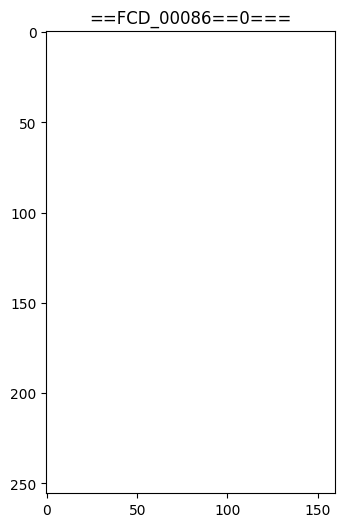

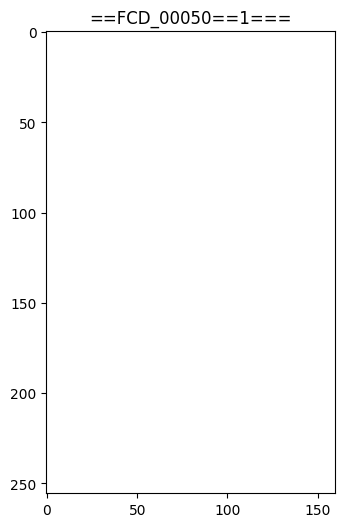

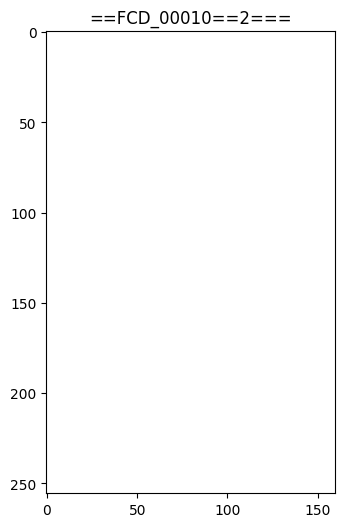

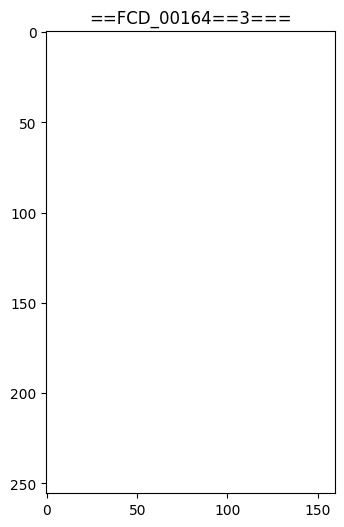

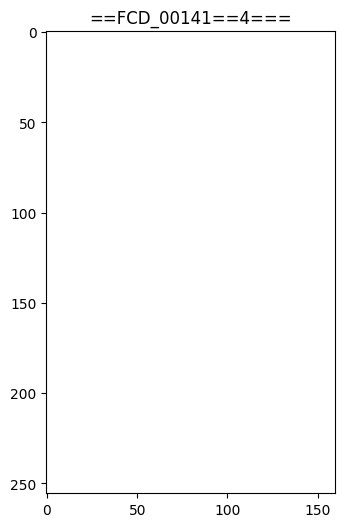

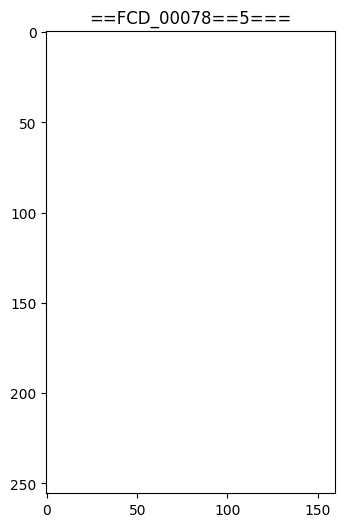

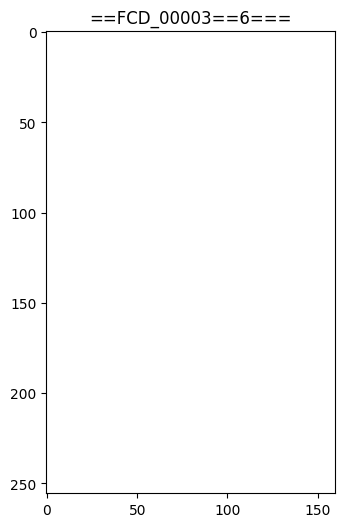

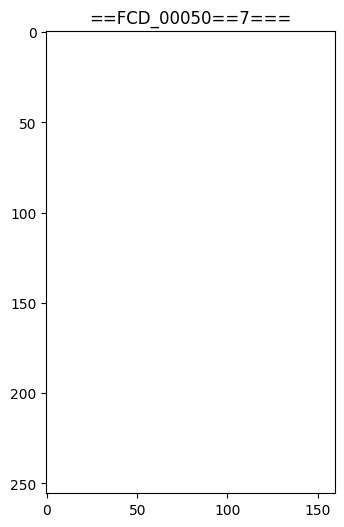

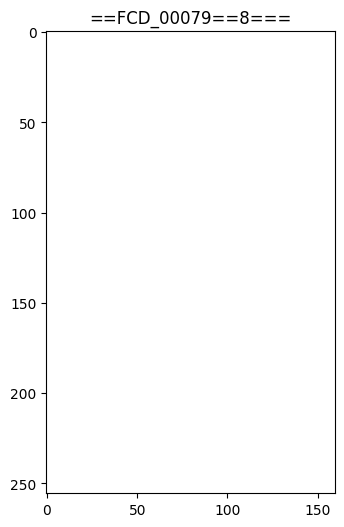

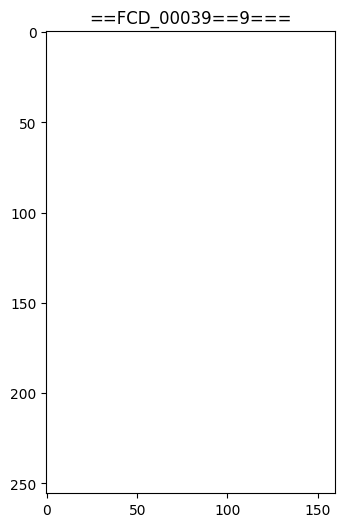

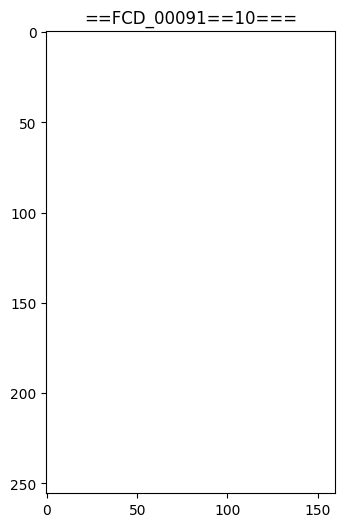

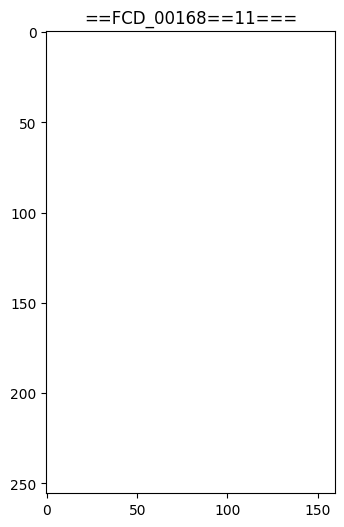

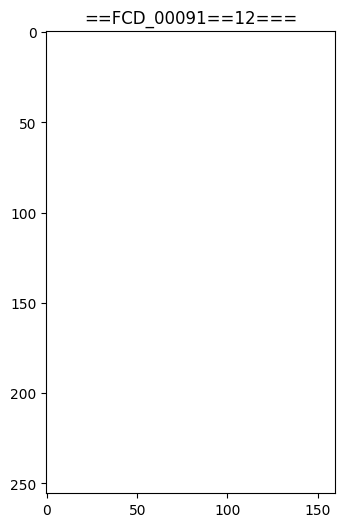

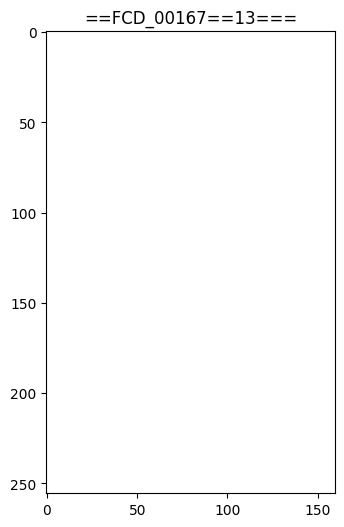

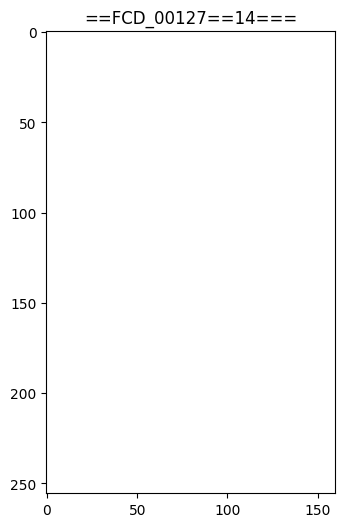

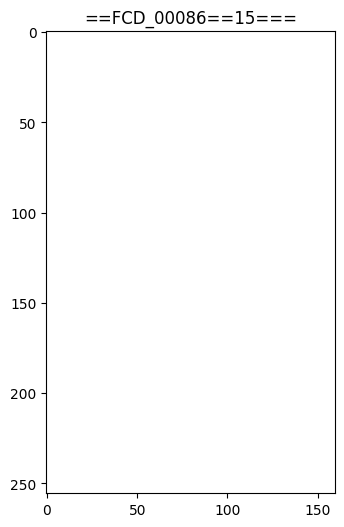

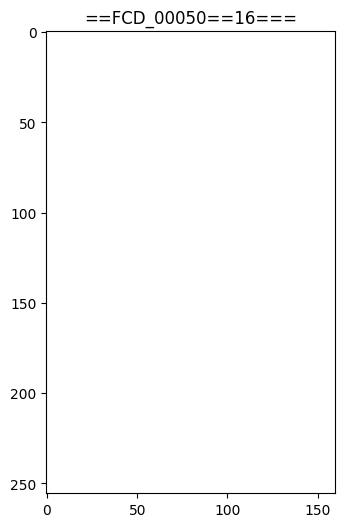

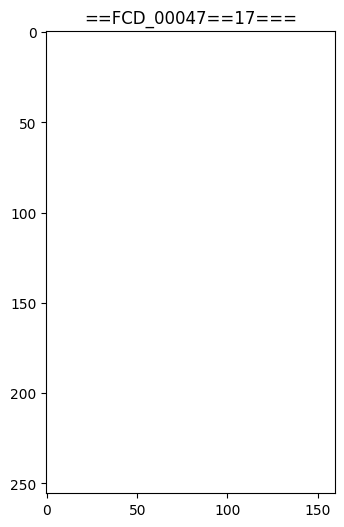

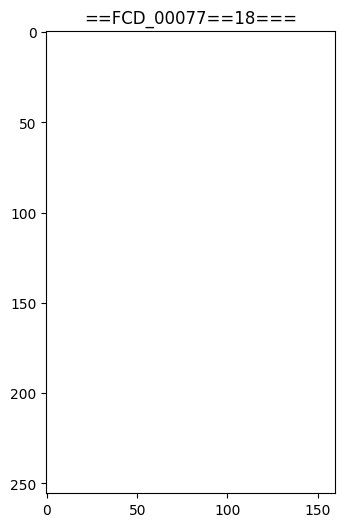

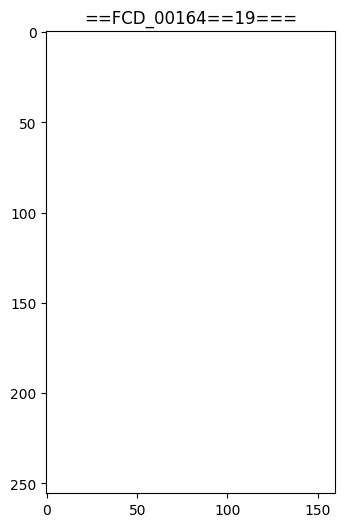

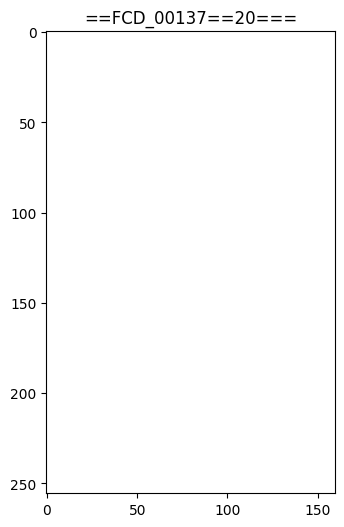

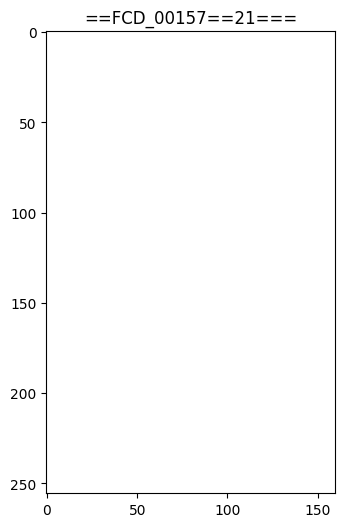

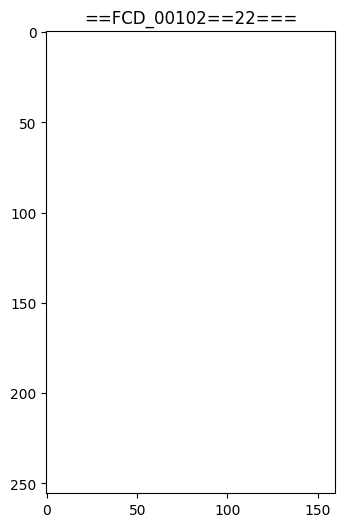

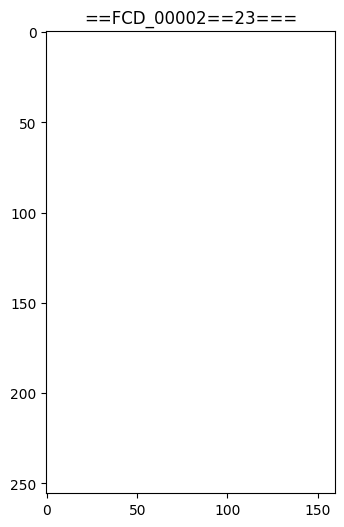

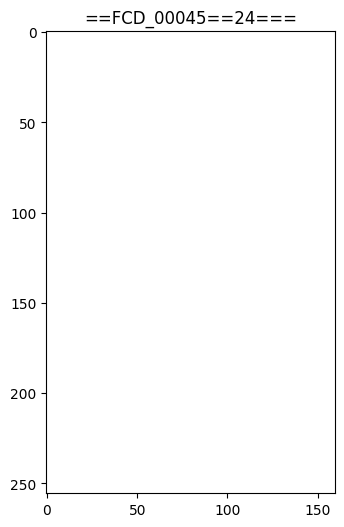

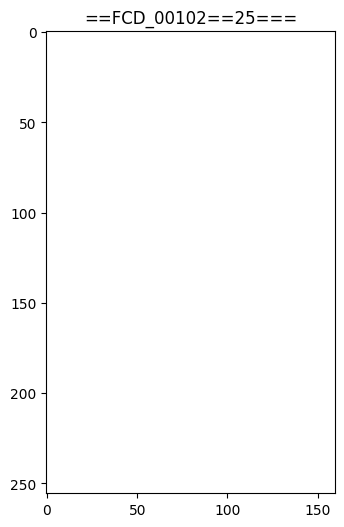

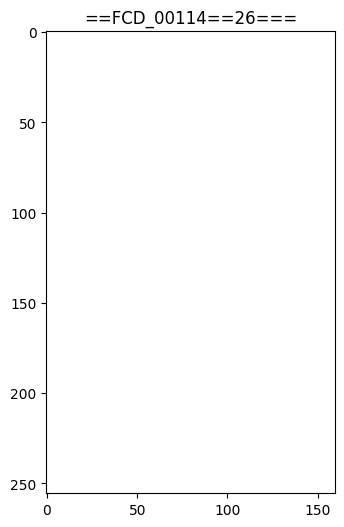

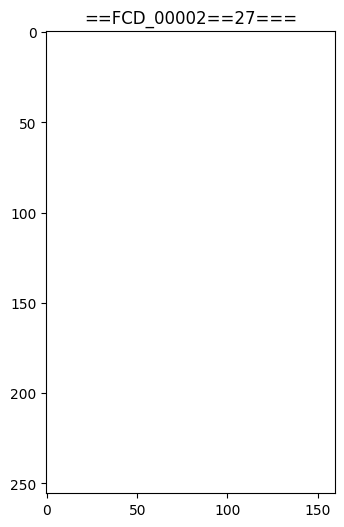

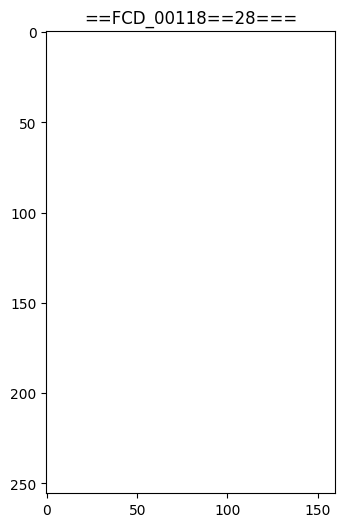

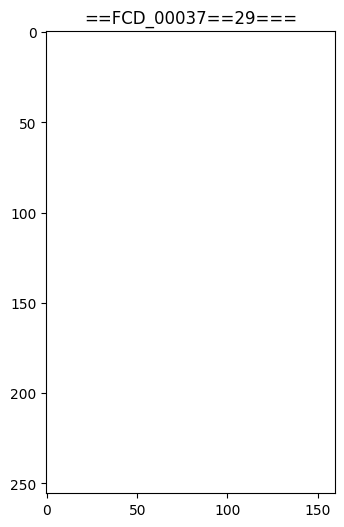

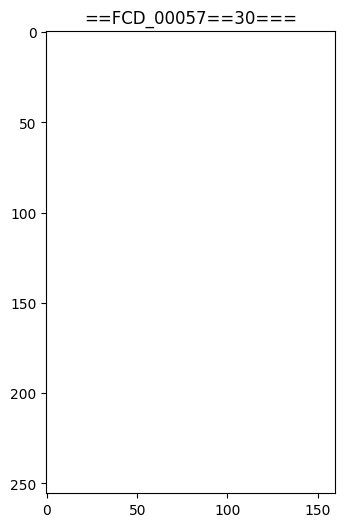

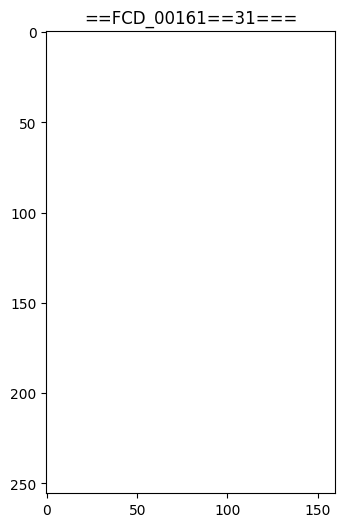

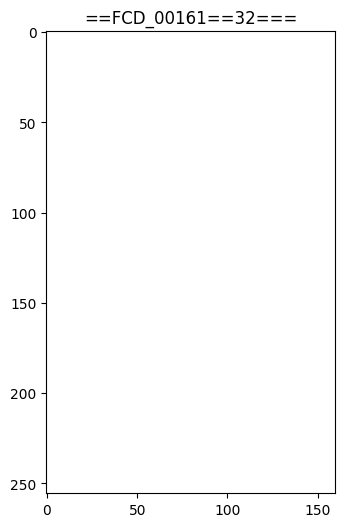

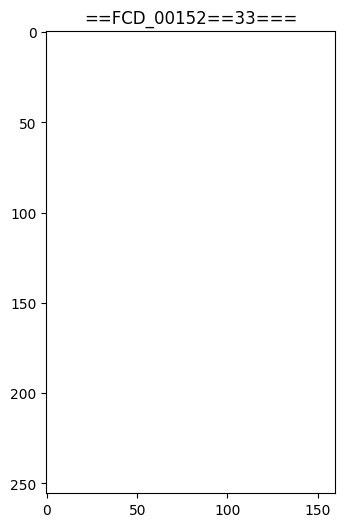

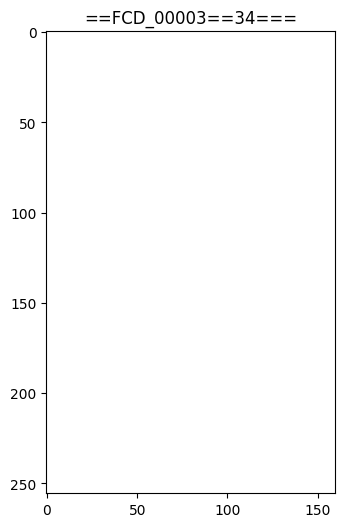

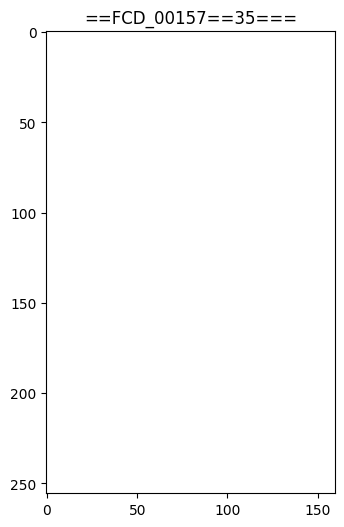

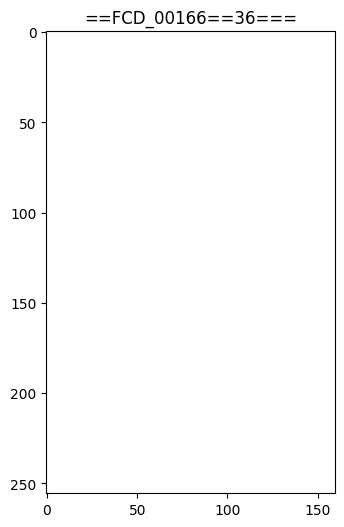

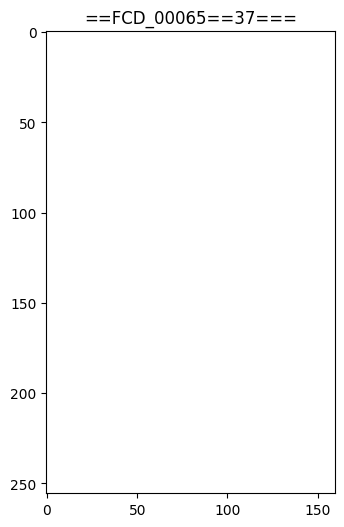

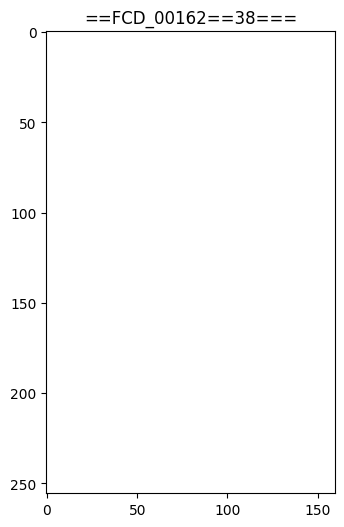

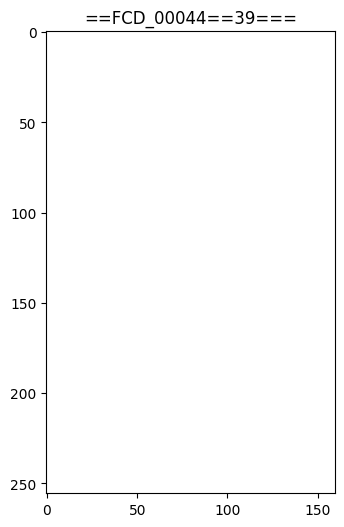

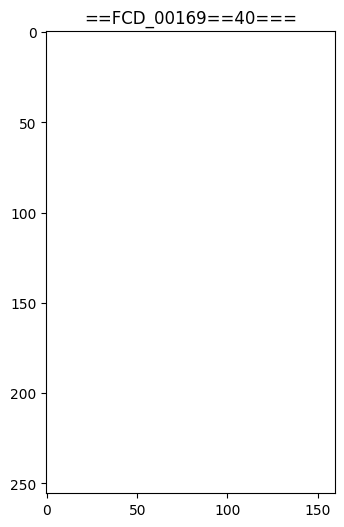

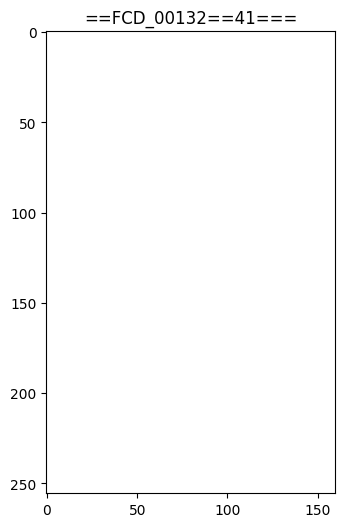

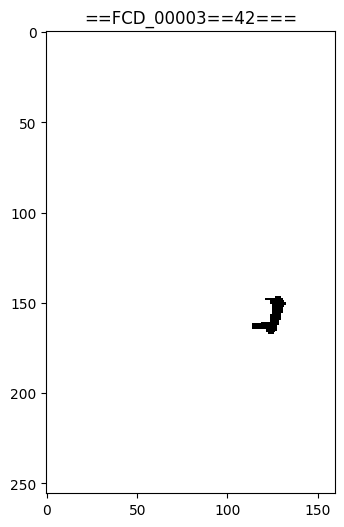

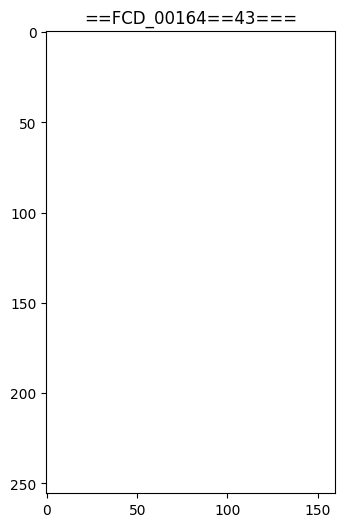

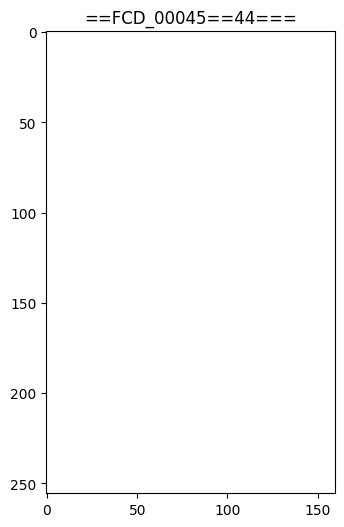

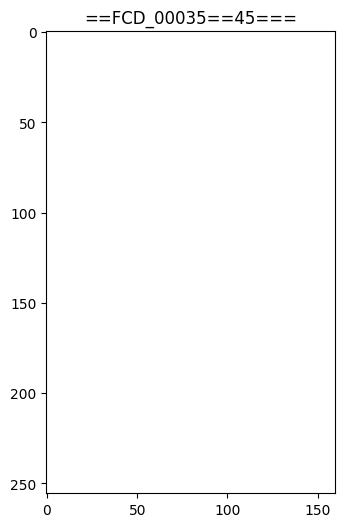

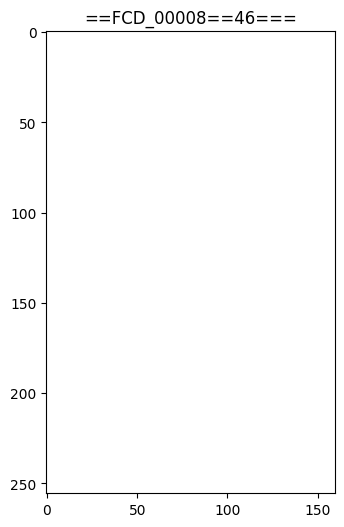

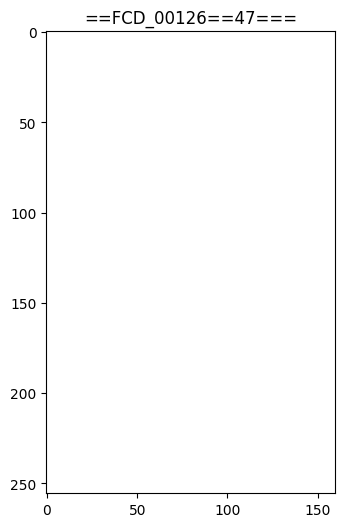

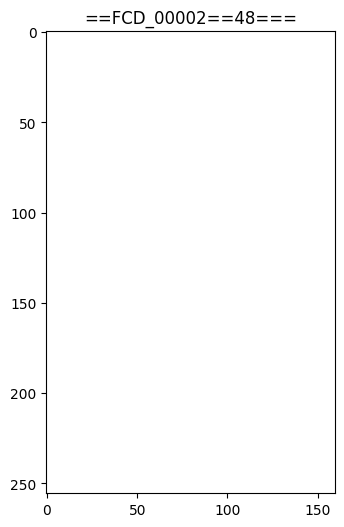

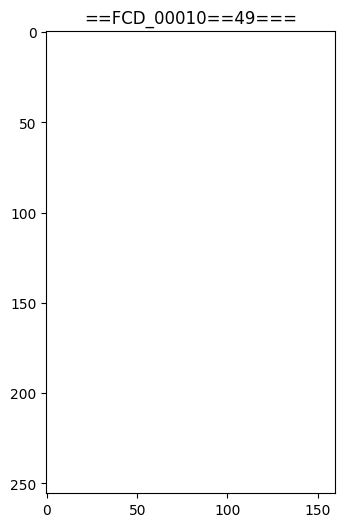

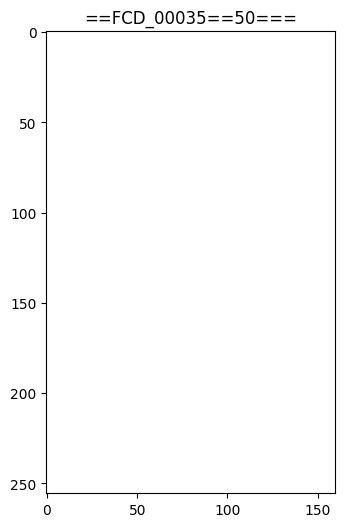

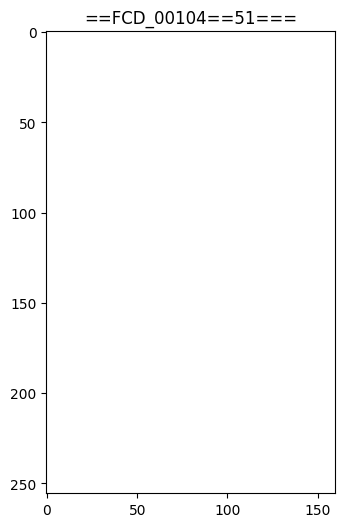

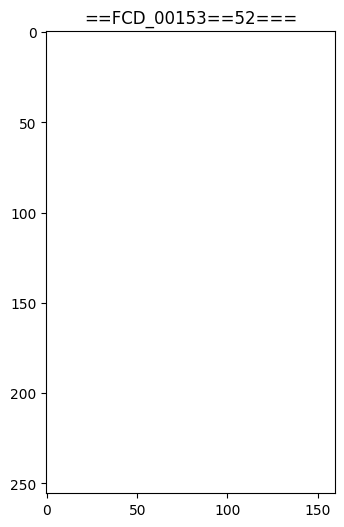

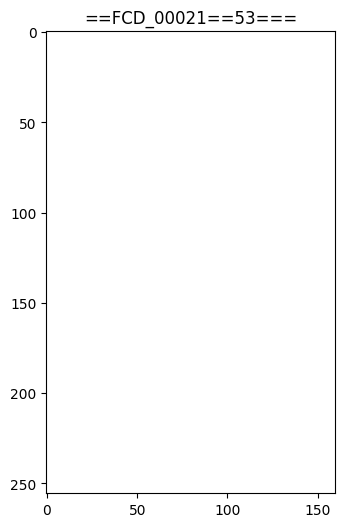

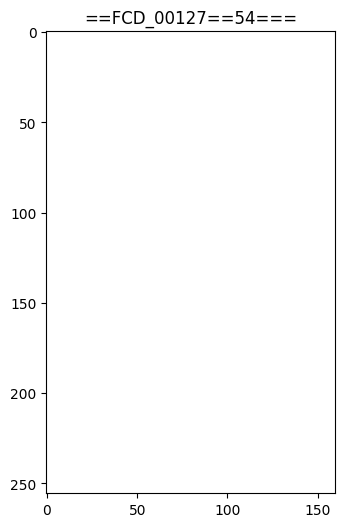

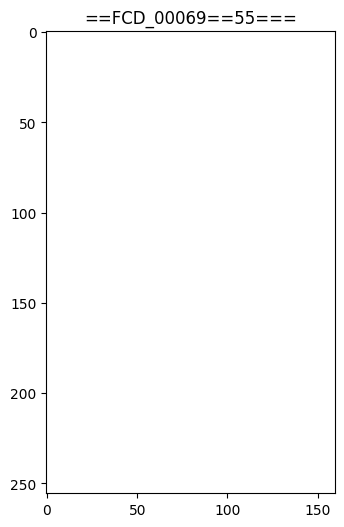

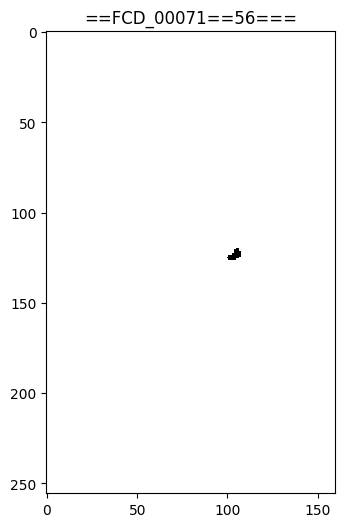

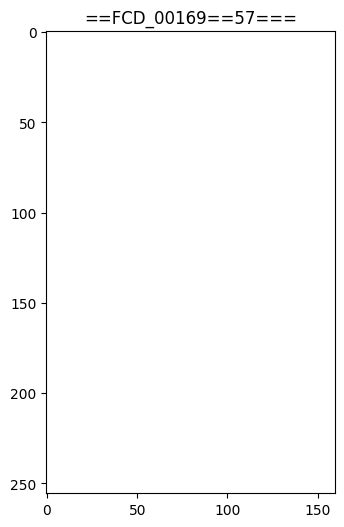

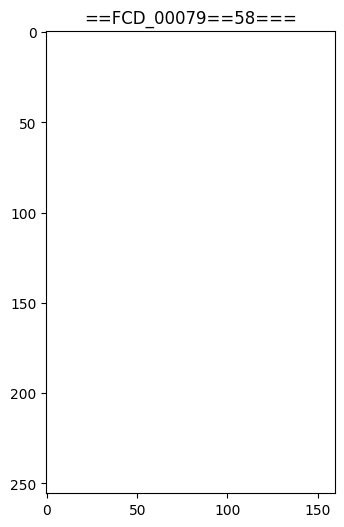

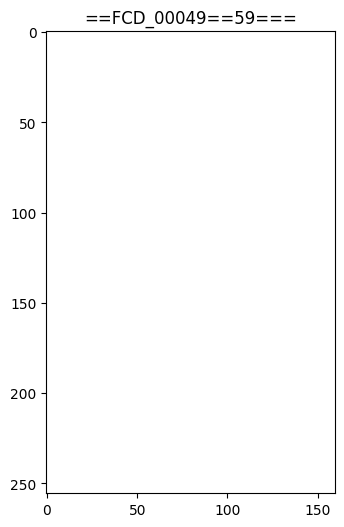

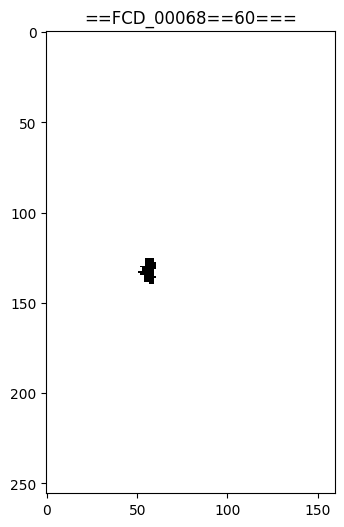

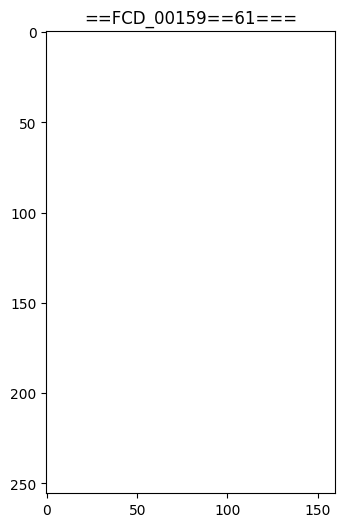

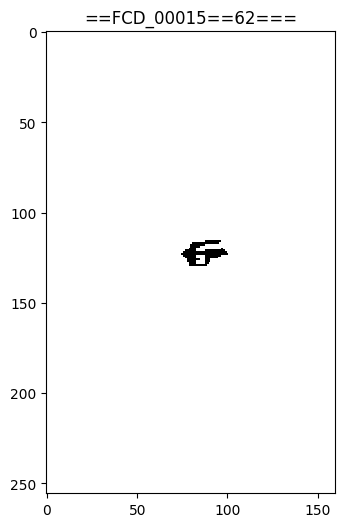

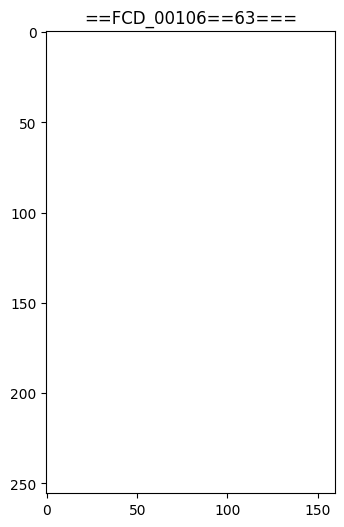

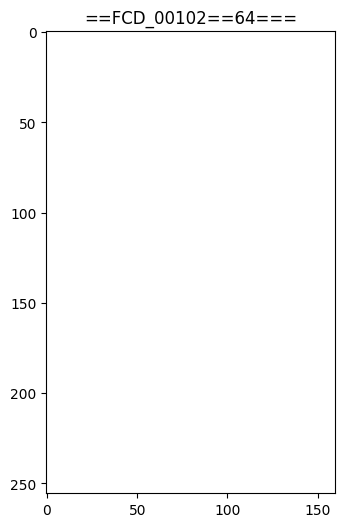

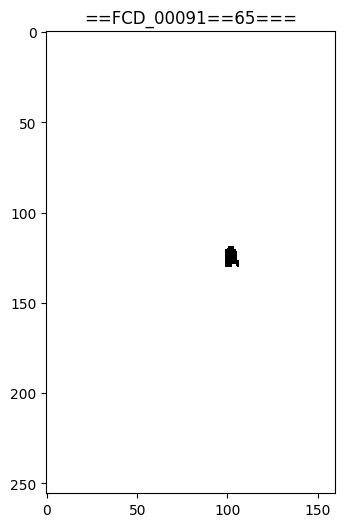

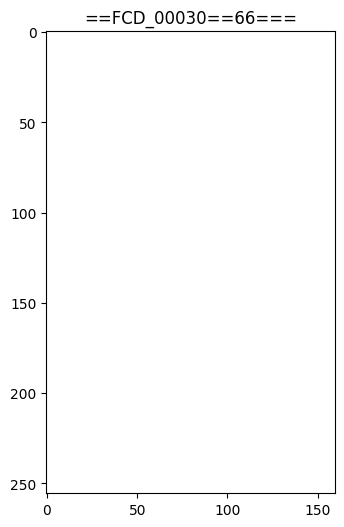

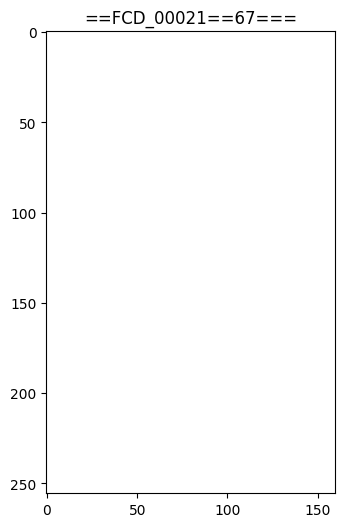

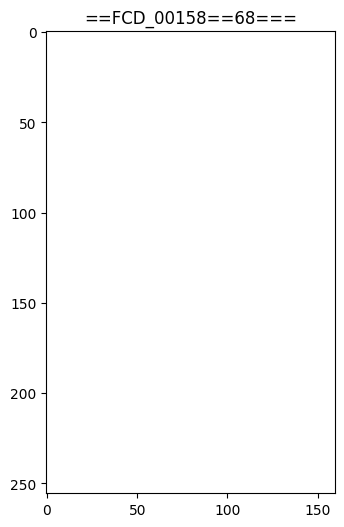

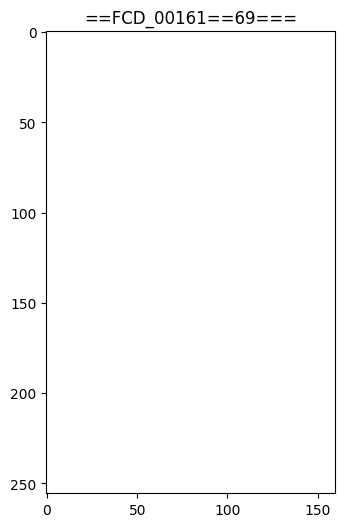

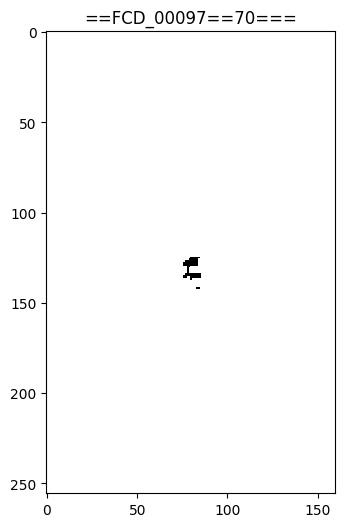

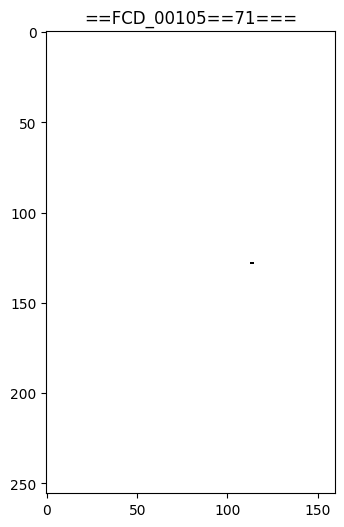

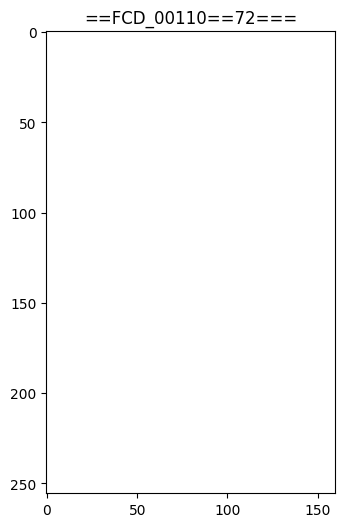

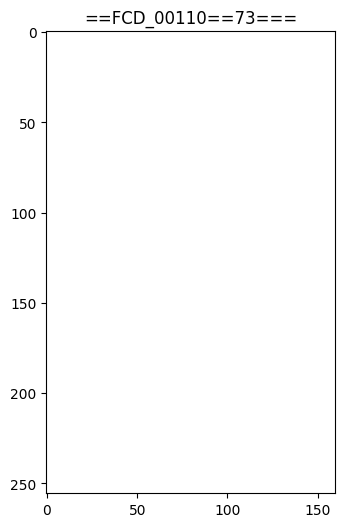

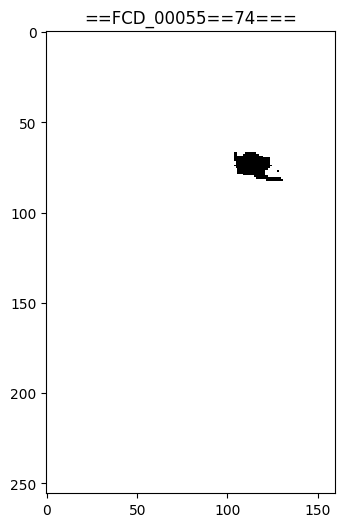

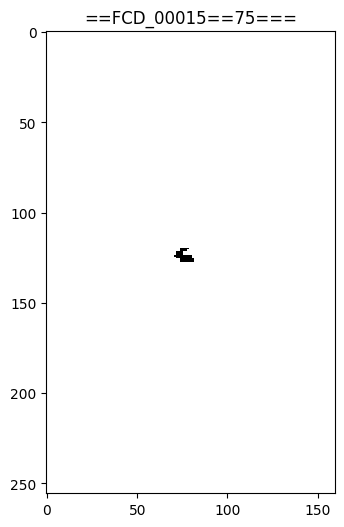

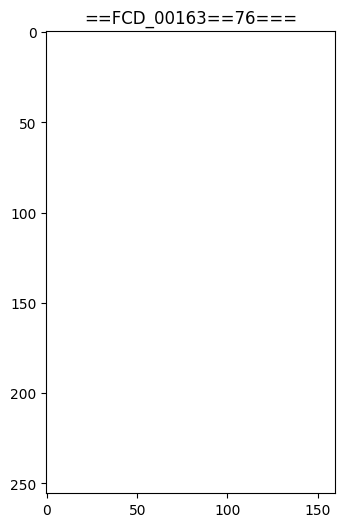

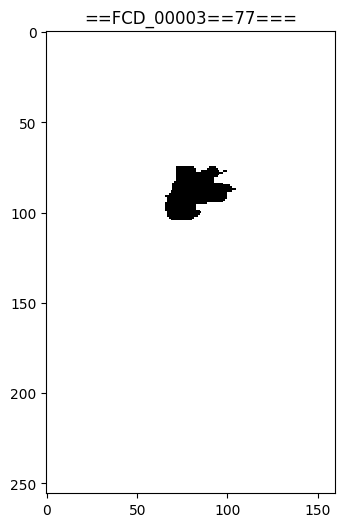

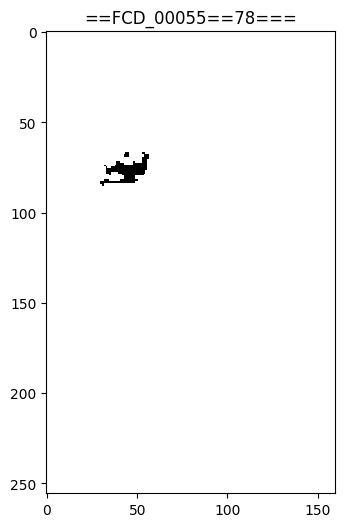

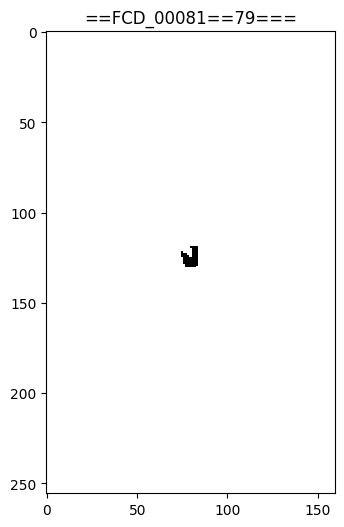

In [208]:


import numpy as np
import matplotlib.pyplot as plt

# Suppose you loaded your array
# arr = np.load(path)   # shape (1, 1, 339, 188)

# Squeeze to remove (1,1) dimensions -> shape (339,188)
# for i in range(80):
i = 0
for arr, key in zip(batch['target'][0],batch['keys']):
    # print(j,i.detach().cpu().numpy())

    arr2d = arr.detach().cpu().numpy().squeeze()
    

    
    # --- Visualization using Matplotlib ---
    
    plt.figure(figsize=(6, 6)) # Set a good figure size
    
    # Use imshow to display the array as an image
    # cmap='binary' or 'gray' is good for 1s and 0s.
    # interpolation='nearest' ensures sharp, blocky pixels.
    plt.imshow(arr2d, cmap='binary', interpolation='nearest')
    
    # Add a title
    
    plt.title("=={}=={}===".format(key,i))

    
    plt.show()
    i+=1




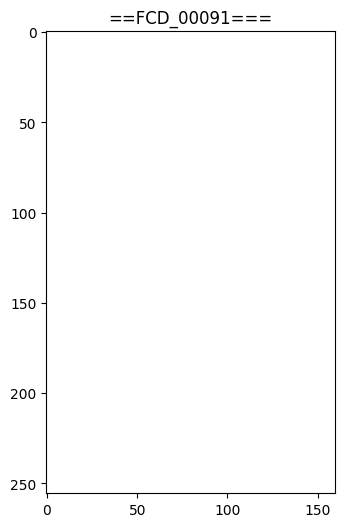

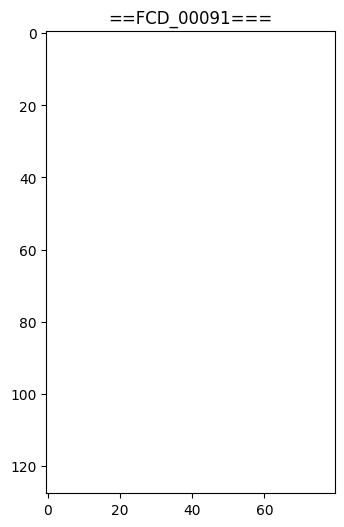

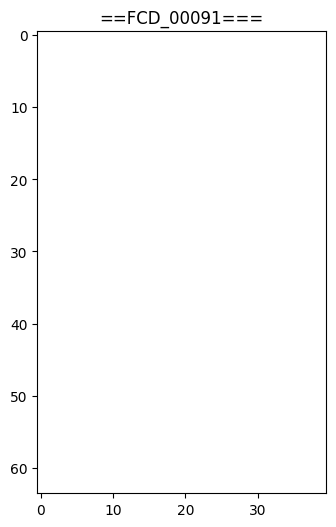

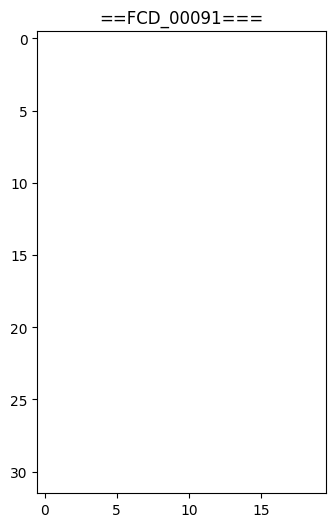

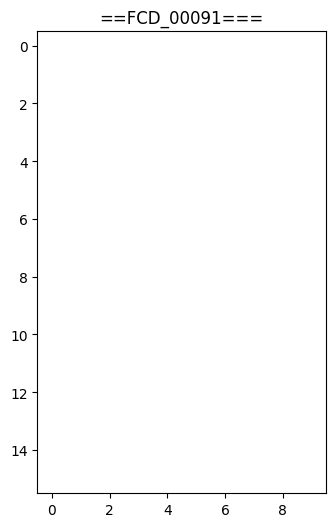

In [167]:

import numpy as np
import matplotlib.pyplot as plt

# Suppose you loaded your array
# arr = np.load(path)   # shape (1, 1, 339, 188)

# Squeeze to remove (1,1) dimensions -> shape (339,188)
# for i in range(80):
# for arr, key in zip(batch['target'][],):
#     # print(j,i.detach().cpu().numpy())

for i in range(5):
    arr = batch['target'][i][4]
    arr2d = arr.detach().cpu().numpy().squeeze()
    

    
    # --- Visualization using Matplotlib ---
    
    plt.figure(figsize=(6, 6)) # Set a good figure size
    
    # Use imshow to display the array as an image
    # cmap='binary' or 'gray' is good for 1s and 0s.
    # interpolation='nearest' ensures sharp, blocky pixels.
    plt.imshow(arr2d, cmap='binary', interpolation='nearest')
    
    # Add a title
    plt.title("=={}===".format(batch['keys'][4]))

    
    plt.show()

FCD00068为第四个

In [134]:
count_ones = np.sum(arr2d == 1)
print("Number of 1s:", count_ones)

Number of 1s: 0


In [135]:
count_ones = np.sum(arr2d == 0)
print("Number of 1s:", count_ones)

Number of 1s: 40960


In [136]:
arr2d.shape

(256, 160)

In [ ]:
import pickle

# Example object
data = {'a': 1, 'b': [1, 2, 3]}

# Save to a file
with open('data.pkl', 'wb') as f:  # 'wb' = write binary
    pickle.dump(data, f)


In [172]:
import pickle

# Load from file
with open('data.pkl', 'rb') as f:  # 'rb' = read binary
    batch = pickle.load(f)

print(loaded_data.keys())


dict_keys(['data', 'target', 'keys', 'ori_data', 'mask', 'data_grad', 'data_grad_masked', 'perturbation', 'adv_data'])


In [173]:
 batch['target'][0][2].detach().cpu().numpy()

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 256, 160), dtype=int16)

In [211]:
i = 42
keys_ = ['data', 'target', 'keys', 'ori_data', 'mask', 'data_grad', 'data_grad_masked', 'perturbation', 'adv_data']
channel_names= {"T1":0,"FLAIR":1}
type = 'FLAIR'
key = 'FCD_00003'
print(
batch['ori_data'][i,channel_names[type],:,:].detach().cpu().numpy().shape,
batch['target'][0][i][0].detach().cpu().numpy().shape,
batch['mask'][i][0].detach().cpu().numpy().shape,
batch['data_grad'][i][0].detach().cpu().numpy().shape,
batch['data_grad_masked'][i][0].detach().cpu().numpy().shape,
batch['perturbation'][i][0].detach().cpu().numpy().shape,
batch['adv_data'][i][0].detach().cpu().numpy().shape,
batch['keys'].tolist()[i])

(256, 160) (256, 160) (256, 160) (256, 160) (256, 160) (256, 160) (256, 160) FCD_00003


# Draw mask

In [304]:

def display_image_with_mask(original_image, binary_mask, alpha=0.5):
    """
    Displays the original grayscale image with a transparent blue overlay
    based on the binary mask.

    Args:
        original_image (np.ndarray): The original grayscale image (H, W).
                                     Expected to be uint8 or float in [0, 1].
        binary_mask (np.ndarray): The binary mask (H, W) with 0s and 1s.
        alpha (float): The transparency level of the blue overlay (0.0 to 1.0).
    """
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image, cmap='gray')  # Display original grayscale image

    # Create an RGBA image for the mask to overlay
    # This leverages matplotlib's ability to blend directly
    mask_rgba = np.zeros((*binary_mask.shape, 4))
    mask_rgba[binary_mask == 1, 2] = 1.0  # Blue channel for mask area
    mask_rgba[binary_mask == 1, 3] = alpha # Alpha channel for transparency

    plt.imshow(mask_rgba, vmin=-1,vmax=4) # Overlay the transparent blue mask
    plt.title(f'Original Image with Blue Mask (alpha={alpha})')
    plt.axis('off')
    plt.savefig( './6.png',bbox_inches='tight')
    plt.show()



In [305]:
ori_data.max()

np.float32(3.085168)

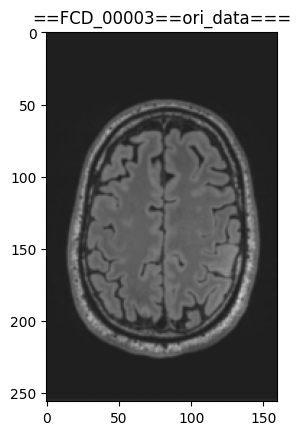

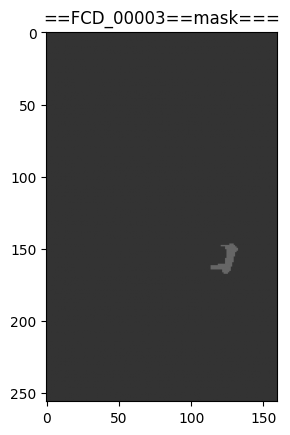

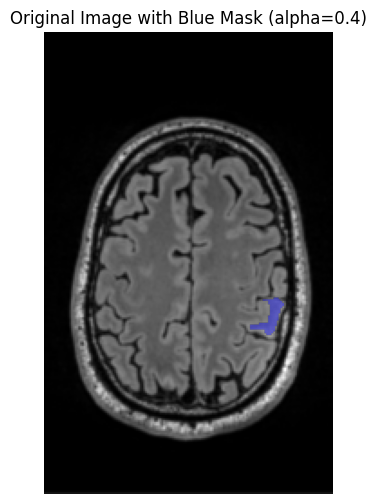

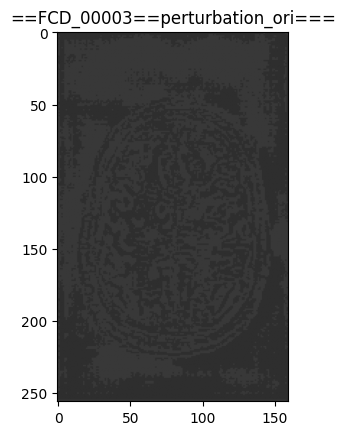

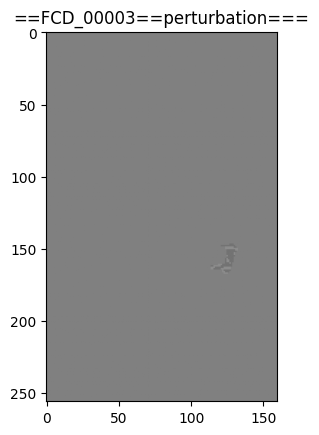

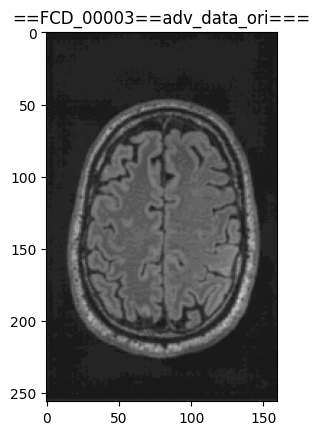

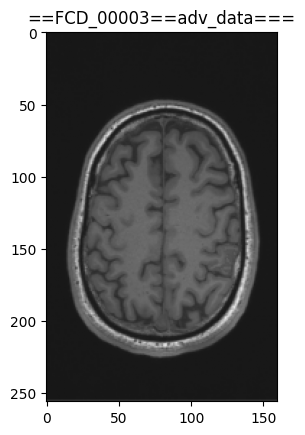

In [307]:

epsilon = 0.1
ori_data = batch['ori_data'][i,channel_names[type],:,:].detach().cpu().numpy()
mask = batch['mask'][i][0].detach().cpu().numpy()
perturbation = batch['perturbation'][i][0].detach().cpu().numpy()
perturbation_ori = epsilon * batch['data_grad'][i][0].detach().cpu().numpy()
adv_data_ori = ori_data + perturbation_ori

adv_data = batch['adv_data'][i][0].detach().cpu().numpy()



plt.imshow(ori_data, cmap='gray', vmin=-1,vmax=4)
plt.title("=={}=={}===".format(key,'ori_data'))
plt.savefig( './0.png',bbox_inches='tight')
plt.show()

plt.imshow(mask, cmap='gray', vmin=-1,vmax=4)
plt.title("=={}=={}===".format(key,'mask'))
plt.savefig( './1.png',bbox_inches='tight')
plt.show()

display_image_with_mask(ori_data, mask, alpha=0.4)

plt.imshow(perturbation_ori, cmap='gray', vmin=-1,vmax=4)
plt.title("=={}=={}===".format(key,'perturbation_ori'))
plt.savefig( './2.png',bbox_inches='tight')
plt.show()


plt.imshow(perturbation, cmap='gray', vmin=-1,vmax=1)
plt.title("=={}=={}===".format(key,'perturbation'))
plt.savefig( './3.png',bbox_inches='tight')
plt.show()

plt.imshow(adv_data_ori, cmap='gray', vmin=-1,vmax=4)
plt.title("=={}=={}===".format(key,'adv_data_ori'))
plt.savefig( './4.png',bbox_inches='tight')
plt.show()

plt.imshow(adv_data, cmap='gray', vmin=-1,vmax=4)
plt.title("=={}=={}===".format(key,'adv_data'))
plt.savefig( './5.png',bbox_inches='tight')
plt.show()


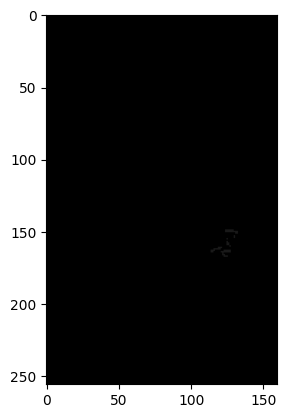

In [285]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from matplotlib.colors import NoNorm
plt.imshow(perturbation,cmap='gray',norm=NoNorm())
# image = Image.open(fname).convert("L")
# arr = np.asarray(image)
# plt.imshow(perturbation, cmap='gray', vmin=-0.1, vmax=0.1)
plt.show()

In [271]:
perturbation.min()

np.float32(-0.1)

error: OpenCV(4.12.0) /io/opencv/modules/core/src/arithm.cpp:687: error: (-5:Bad argument) When the input arrays in add/subtract/multiply/divide functions have different types, the output array type must be explicitly specified in function 'arithm_op'
